[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rycroft-group/math513/blob/main/6_iter/6_iter.ipynb)

In [1]:
# Necessity libraries
import numpy as np
import matplotlib.pyplot as plt

# Optional: a library for plotting with LaTeX-like
# styles nicer formatted figures
# Warning: need to have LaTeX installed
import scienceplots
plt.style.use(['science'])

In [2]:
import os
os.makedirs("results", exist_ok=True)

# Unit 6: Iterative methods

## Lecture 34: More on Arnoldi iteration

### Code demo 1: Use Arnoldi iteration to approximate eigenvalues of a matrix

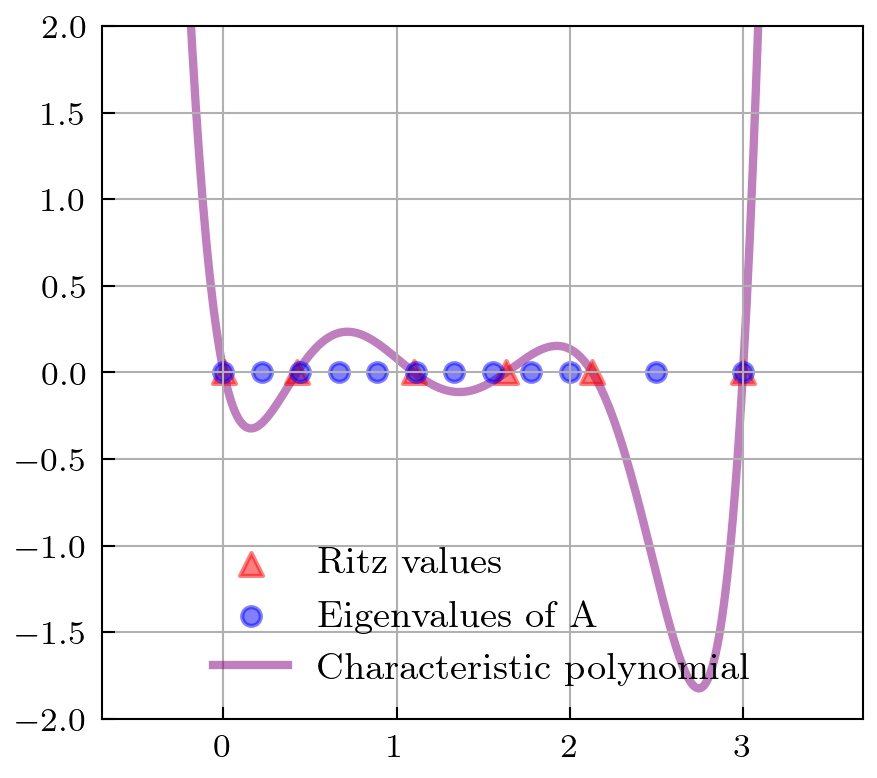

Ritz values:
[2.99945187e+00 2.64075668e-03 2.12948846e+00 1.63216650e+00
 4.25762408e-01 1.09951419e+00]


In [3]:
# Define the vector A
w = 10
diag_vector = np.concatenate([np.linspace(0, 2, w), [2.5, 3.0]])
A = np.diag(diag_vector)
m = w + 2

# Initialize Q, alpha, and beta
n_max = 6
Q = np.zeros((m, n_max))

# Define a random initial vector
b = np.random.randn(m)
Q[:, 0] = b / np.linalg.norm(b)

# The Arnoldi iteration loop
for n in range(n_max - 1):
    v = A @ Q[:, n]
    for l in range(n + 1):
        s = np.dot(Q[:, l].conj(), v)
        v = v - s * Q[:, l]
    b = np.linalg.norm(v)
    Q[:, n + 1] = v / b

H_n = Q.T @ A @ Q
V = np.linalg.eigvals(H_n)

fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)
# Plot the roots
ax.scatter(V, np.zeros_like(V), s=30, marker='^', color='r', label='Ritz values', alpha=0.5)
ax.scatter(diag_vector, np.zeros_like(diag_vector), s=20, color='blue', label='Eigenvalues of A', alpha=0.5)
# Plot the characteristic polynomial
p = np.poly(H_n)
xrange = np.arange(-0.5, 3.5, 0.01)
ax.plot(xrange, np.polyval(p, xrange), color='purple', linewidth=2, label='Characteristic polynomial', zorder=0, alpha=0.5)

# Formatting
ax.set_ylim(-2, 2)
ax.legend(loc='lower center', fontsize=9)
# Prettify
ax.grid(True, linewidth=0.5)
ax.set_aspect('equal')
# ax.set_xlim(-0.5, 3.5)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)

# Save the figure
# plt.savefig("results/arnoldi.pdf", bbox_inches='tight', dpi=300)
plt.show()

# Print out the Ritz values
print("Ritz values:")
print(V)

## Lecture 35: Lanczos iteration

### Code demo 1: Find eigenvalues of a symmetric matrix

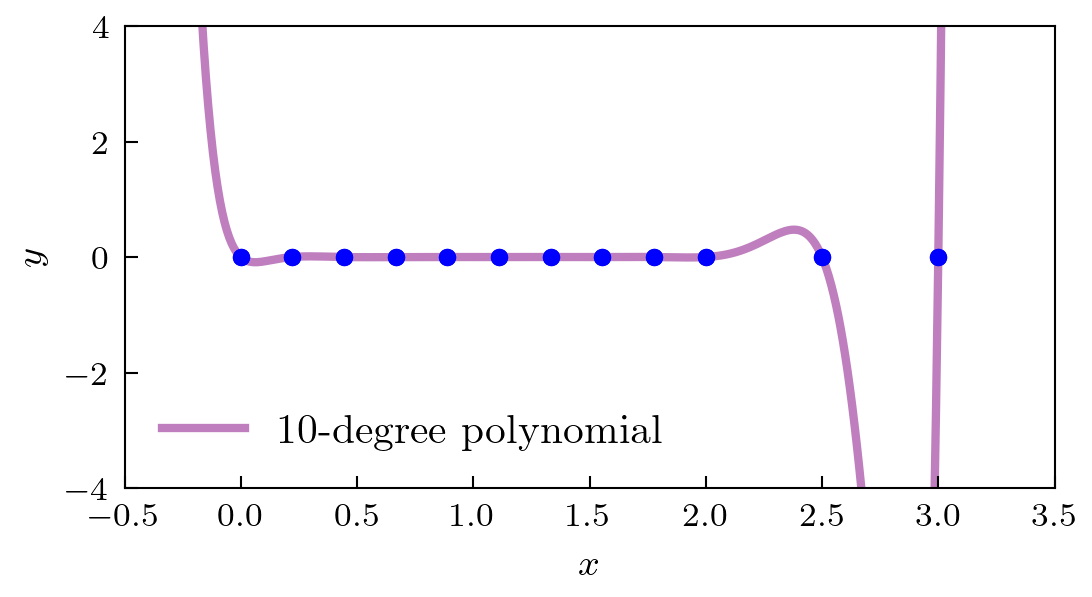

In [4]:
# Define the vector A
n = 10
diag_vector = np.concatenate((np.linspace(0., 2., n), np.array([2.5, 3.])))
A = np.diag(diag_vector)

# Initialize Q, alpha and beta
iters = 11
Q = np.zeros((n+2, iters+1))
alpha = np.zeros((iters))
beta = np.zeros((iters))

# Define a random initial vector
b = np.random.randn(n+2)
Q[:, 0] = b/np.linalg.norm(b)

# The Lanczos iteration loop
for m in range(iters):
    v = np.dot(A, Q[:, m])
    alpha[m] = np.dot(Q[:, m], v)
    if m == 0:
        v = v-alpha[m]*Q[:, m]
    else:
        v = v-beta[m-1]*Q[:, m-1]-alpha[m]*Q[:, m]
    beta[m] = np.linalg.norm(v)
    Q[:, m+1] = v/beta[m]

H_m = np.dot(np.dot(Q.T, A), Q)
[V, D] = np.linalg.eig(H_m)

# Store the characteristic polynomial
results_cp = []
p = np.poly(H_m)
x = -0.5
while x <= 3.5:
    results_cp.append((x, np.polyval(p, x)))
    x += 0.01

# Store the roots
results_roots = []
for i in range(n+2):
    results_roots.append((diag_vector[i], 0))
for i in range(iters+1):
    results_roots.append((V[i], 0))

# Visualize
x_plot, y_plot = zip(*results_cp)
roots = np.array(results_roots)
fig, ax = plt.subplots(1, 1, figsize=(4, 2), dpi=300)
ax.scatter(roots[:, 0], roots[:, 1], s=10, color='blue')
ax.plot(x_plot, y_plot, color='purple', linewidth=2,zorder=0, alpha=0.5, label=str(n)+'-degree polynomial')
# Formatting
ax.set_xlabel('$x$', fontsize=9)
ax.set_ylabel('$y$', fontsize=9)
ax.set_xlim(-0.5, 3.5)
ax.set_ylim(-4, 4)
# Prettify
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)
ax.legend()

# Save the figure
# plt.savefig("results/lanczos.pdf", bbox_inches='tight', dpi=300)
plt.show()

## Lecture 36: GMRES

### Code demo 1: Convergence of GMRES

Let $A$ be a $200 \times 200$ matrix whose entries are independent samples from the real normal distribution of mean $2$ and standard deviation $0.5/\sqrt{200}$.

Show the convergence for the GMRES iteration applied to the linear system $Ax=b$ where $b=[1,1,\ldots,1]^*$.

In [5]:
# Construct matrix A
m = 200
np.random.seed(42)
A = 2*np.eye(m) + 0.5/np.sqrt(200)*np.random.randn(m, m)
# Set the maximum number of iterations for GMRES
n_max = 10
# Right-hand side
b = np.ones(m)

# Initialize quantity for GMRES
Q = np.zeros((m, n_max + 1))        # Q_n and Q_{n+1}
Ht_n = np.zeros((n_max + 1, n_max)) # \tilde{H}_n
Q[:, 0] = b / np.linalg.norm(b)     # q_0 = b / ||b||
# Store the solution and residuals
x_n = np.zeros(m)
gmres_residuals = []

# GMRES iteration loop
for n in range(n_max):
    # 1. Step n of Arnoldi iteration
    v = A @ Q[:, n]                     # v = A q_n
    for j in range(n+1):
        Ht_n[j, n] = np.dot(Q[:, j], v) # h_jn = q_j^* v
        v = v - Ht_n[j, n] * Q[:, j]    # v = v - h_jn q_j
    Ht_n[n + 1, n] = np.linalg.norm(v)  # h_{n+1,n} = ||v||
    Q[:, n + 1] = v / Ht_n[n + 1, n]    # q_{n+1} = v / h_{n+1,n}

    # 2. Find y for min || \tilde{H}_n y - ||b|| e1 ||
    rhs = np.zeros(n + 2)      # e_1 = [1, 0, ..., 0]^T
    rhs[0] = np.linalg.norm(b) # ||b|| e_1
    y, *_ = np.linalg.lstsq(Ht_n[:n + 2, :n + 1], rhs, rcond=None)

    # 3. GMRES iterate
    x_n = Q[:, :n + 1] @ y
    residual = np.linalg.norm(b - A @ x_n) / np.linalg.norm(b)
    gmres_residuals.append(residual)

    # 4. Check for convergence
    if residual < 1e-16:
        break

Let us plot the eigenvalues of A on the complex plane, and look at the convergence rate as a function of the number of iterations.

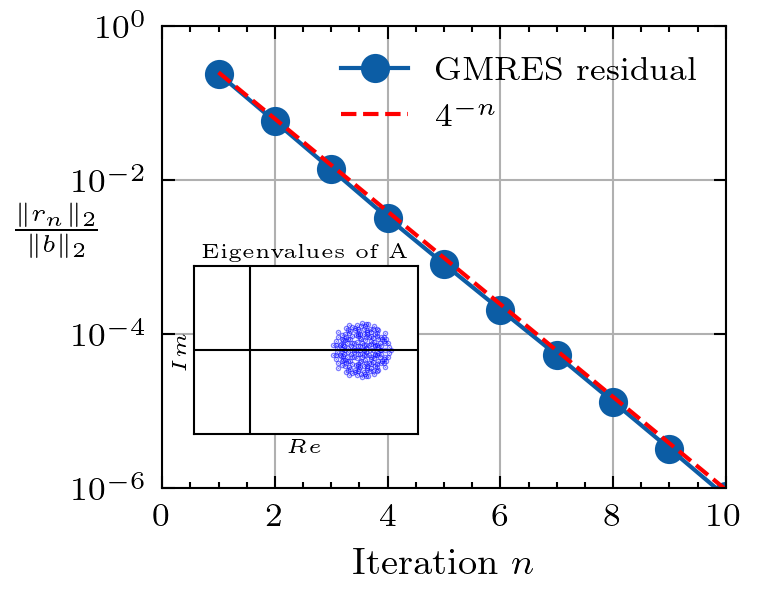

In [6]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(4, 2), dpi=300)
gs = GridSpec(1, 2, width_ratios=[0.5, 1.], figure=fig)
ax_main = fig.add_subplot(gs[0, 1])
ax_inset = fig.add_axes([0.45, 0.2, 0.2, 0.28])

# Plot eigenvalues of A in inset
eigs = np.linalg.eigvals(A)
real_eigs = np.real(eigs)
img_eigs = np.imag(eigs)
ax_inset.scatter(real_eigs, img_eigs, s=0.1, color='blue', alpha=0.5)
ax_inset.set_xlabel('$Re$', fontsize=5, labelpad=1)
ax_inset.set_ylabel('$Im$', fontsize=5, labelpad=1)
ax_inset.set_title('Eigenvalues of A', fontsize=5, pad=2)
# Prettify
ax_inset.set_xlim(-1, 3)
ax_inset.set_ylim(-1.5, 1.5)
ax_inset.axhline(y=0, color='k', linewidth=0.5)
ax_inset.axvline(x=0, color='k', linewidth=0.5)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.set_aspect('equal')

# Plot convergence in main panel
ax_main.semilogy(range(1, len(gmres_residuals) + 1), gmres_residuals, marker='o', label='GMRES residual')
ax_main.set_xlabel('Iteration $n$', fontsize=9)
ax_main.set_ylabel(r'$\frac{\|r_n\|_2}{\|b\|_2}$', fontsize=9, rotation=0)
ax_main.set_xlim(0, 10)
ax_main.set_ylim(1e-6, 1)
ax_main.grid(True, linewidth=0.5)
ax_main.tick_params(axis='both', which='major', labelsize=8)
# Plot reference convergence line 4^(-n)
ref_line = [4**(-n) for n in range(1, len(gmres_residuals) + 1)]
ax_main.semilogy(range(1, len(gmres_residuals) + 1), ref_line, color='red', linestyle='--', label=r'$4^{-n}$')
ax_main.legend(fontsize=8, loc='upper right')

# Save the figure
# plt.savefig("results/gmres_convergence_well.pdf", bbox_inches='tight', dpi=300)
plt.show()

Let us check the condition number of matrix A.

In [7]:
# Condition number of A
cond_A = np.linalg.cond(A)
print(f"Condition number of A: {cond_A:.2f}")
# Condition number of V
_, V = np.linalg.eig(A)
cond_V = np.linalg.cond(V)
print(f"Condition number of V: {cond_V:.2f}")

Condition number of A: 2.05
Condition number of V: 362.51


We see here that both $A$ and $V$ are relatively small, meaning this is a well-conditioned problem for GMRES, and it's not too far away from normality.

What if we look at another matrix $A$ whose eigenvalues are not clustered? What would that do to the convergence rate of GMRES?

Now, let $A' = A + D$ be a $200 \times 200$ matrix, where $D$ is the diagonal matrix with complex entries $d_k = (-2 + 2 \sin \theta_k) + i \cos \theta_k$ where $\theta_k = \frac{k \pi}{m-1}, 0 \leq k \leq m-1$.

In [8]:
# Construct matrix A
m = 200
np.random.seed(42)
A = 2*np.eye(m) + 0.5/np.sqrt(200)*np.random.randn(m, m)
# Construct matrix D
k = np.arange(m)
theta = k * np.pi/(m-1)
D = np.diag((-2.+2*np.sin(theta)) + 1j * np.cos(theta))
Ap = A + D
# Set the maximum number of iterations for GMRES
n_max = 10
# Right-hand side
b = np.ones(m)

# Initialize quantity for GMRES
Q = np.zeros((m, n_max + 1))        # Q_n and Q_{n+1}
Ht_n = np.zeros((n_max + 1, n_max)) # \tilde{H}_n
Q[:, 0] = b / np.linalg.norm(b)     # q_0 = b / ||b||
# Store the solution and residuals
x_n = np.zeros(m)
gmres_residuals = []

# GMRES iteration loop
for n in range(n_max):
    # 1. Step n of Arnoldi iteration
    v = Ap @ Q[:, n]                     # v = A q_n
    for j in range(n+1):
        Ht_n[j, n] = np.vdot(Q[:, j], v) # h_jn = q_j^* v (complex-safe inner product)
        v = v - Ht_n[j, n] * Q[:, j]     # v = v - h_jn q_j
    Ht_n[n + 1, n] = np.linalg.norm(v)   # h_{n+1,n} = ||v||
    Q[:, n + 1] = v / Ht_n[n + 1, n]     # q_{n+1} = v / h_{n+1,n}

    # 2. Find y for min || \tilde{H}_n y - ||b|| e1 ||
    rhs = np.zeros(n + 2)      # e_1 = [1, 0, ..., 0]^T
    rhs[0] = np.linalg.norm(b) # ||b|| e_1
    y, *_ = np.linalg.lstsq(Ht_n[:n + 2, :n + 1], rhs, rcond=None)

    # 3. GMRES iterate
    x_n = Q[:, :n + 1] @ y
    residual = np.linalg.norm(b - Ap @ x_n) / np.linalg.norm(b)
    gmres_residuals.append(residual)

    # 4. Check for convergence
    if residual < 1e-16:
        break

/var/folders/dc/yjt5l_9s0d752c4rt46gd2qh0000gn/T/ipykernel_49829/1677821391.py:28: ComplexWarning: Casting complex values to real discards the imaginary part
  Ht_n[j, n] = np.vdot(Q[:, j], v) # h_jn = q_j^* v (complex-safe inner product)
/var/folders/dc/yjt5l_9s0d752c4rt46gd2qh0000gn/T/ipykernel_49829/1677821391.py:31: ComplexWarning: Casting complex values to real discards the imaginary part
  Q[:, n + 1] = v / Ht_n[n + 1, n]     # q_{n+1} = v / h_{n+1,n}


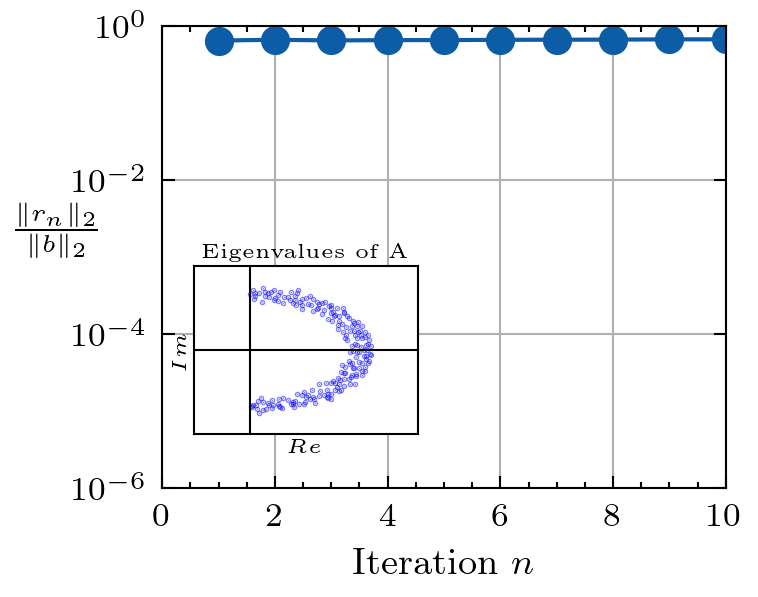

In [9]:

fig = plt.figure(figsize=(4, 2), dpi=300)
gs = GridSpec(1, 2, width_ratios=[0.5, 1.], figure=fig)
ax_main = fig.add_subplot(gs[0, 1])
ax_inset = fig.add_axes([0.45, 0.2, 0.2, 0.28])

# Plot eigenvalues of A in inset
eigs = np.linalg.eigvals(Ap)
real_eigs = np.real(eigs)
img_eigs = np.imag(eigs)
ax_inset.scatter(real_eigs, img_eigs, s=0.1, color='blue', alpha=0.5)
ax_inset.set_xlabel('$Re$', fontsize=5, labelpad=1)
ax_inset.set_ylabel('$Im$', fontsize=5, labelpad=1)
ax_inset.set_title('Eigenvalues of A', fontsize=5, pad=2)
# Prettify
ax_inset.set_xlim(-1, 3)
ax_inset.set_ylim(-1.5, 1.5)
ax_inset.axhline(y=0, color='k', linewidth=0.5)
ax_inset.axvline(x=0, color='k', linewidth=0.5)
ax_inset.set_xticks([])
ax_inset.set_yticks([])
ax_inset.set_aspect('equal')

# Plot convergence in main panel
ax_main.semilogy(range(1, len(gmres_residuals) + 1), gmres_residuals, marker='o', label='GMRES residual')
ax_main.set_xlabel('Iteration $n$', fontsize=9)
ax_main.set_ylabel(r'$\frac{\|r_n\|_2}{\|b\|_2}$', fontsize=9, rotation=0)
ax_main.set_xlim(0, 10)
ax_main.set_ylim(1e-6, 1)
ax_main.grid(True, linewidth=0.5)
ax_main.tick_params(axis='both', which='major', labelsize=8)

# Save the figure
# plt.savefig("results/gmres_convergence_ill.pdf", bbox_inches='tight', dpi=300)
plt.show()

## Lecture 39: Preconditioning

### Code demo 1: Preconditioned conjugate gradient method

In [10]:
m = 1000
np.random.seed(42)
# Construct matrix A
A = np.zeros((m, m))
for i in range(m):
    for j in range(m):
        if i == j:
            A[i, j] = 0.5 + np.sqrt(i)
        elif abs(i - j) == 1 or abs(i - j) == 100:
            A[i, j] = 1.
# Construct RHS vector b
b = np.ones(m)

# Conjugate gradient
def cg(A, F, x0, tol=1e-6, maxiter=100):
    x = x0.copy()
    r = F - A @ x
    p = r.copy()
    xs = [x.copy()]
    rs = [np.linalg.norm(r)]
    for _ in range(maxiter):
        alpha = (r @ r) / (p @ A @ p)
        x = x + alpha * p
        r_new = r - alpha * (A @ p)
        xs.append(x.copy())
        rs.append(np.linalg.norm(r_new))
        if np.linalg.norm(r_new) < tol:
            break
        beta = (r_new @ r_new) / (r @ r)
        p = r_new + beta * p
        r = r_new
    return x, xs, rs

# Sparse binary initial guess: mostly zeros, few ones
p_one = 0.4
x0 = (np.random.rand(m) < p_one).astype(float)
# x0 = np.ones(m)
x_cg, xs_cg, rs_cg = cg(A, b, x0, tol=1e-16, maxiter=100)

In [11]:
M = np.diag(A)
C = np.sqrt(M)
# Preconditioned CG
A_tilde = A / C[:, None] / C[None, :]
b_tilde = b / C
y0 = C * x0

y_pcg, ys_pcg, rs_pcg = cg(A_tilde, b_tilde, y0, tol=1e-18, maxiter=100)

x_pcg = y_pcg / C
xs_pcg = [yk / C for yk in ys_pcg]
rs_pcg = [np.linalg.norm(b - A @ xk) for xk in xs_pcg]

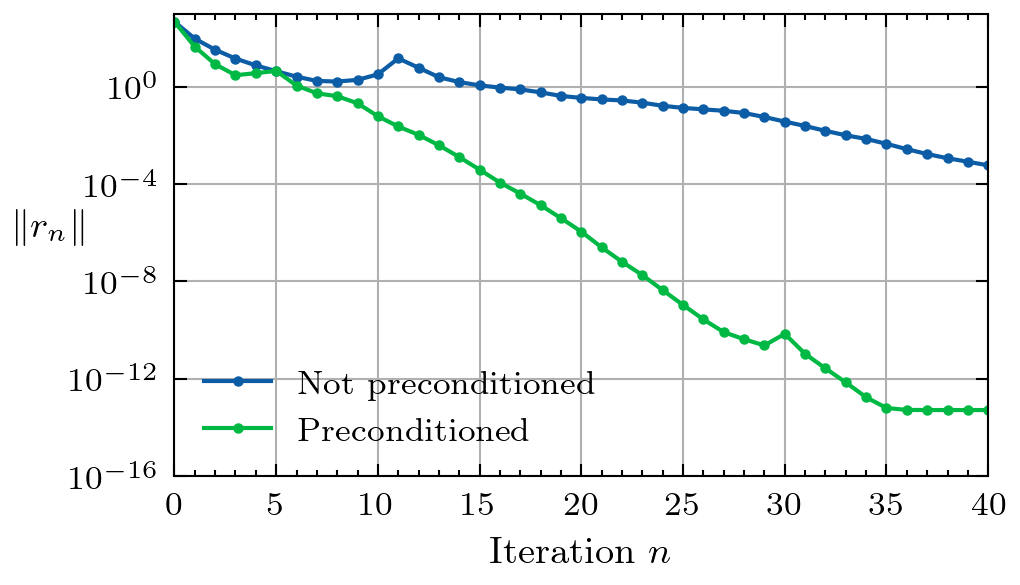

In [12]:
fig, ax = plt.subplots(figsize=(3.5, 2), dpi=300)
ax.semilogy(rs_cg, marker='o', ms=1.5, label='Not preconditioned')
ax.semilogy(rs_pcg, marker='o', ms=1.5, label='Preconditioned')
ax.set_xlabel('Iteration $n$', fontsize=9)
ax.set_ylabel(r'$\|r_n\|$', fontsize=9, rotation=0)
ax.set_xlim(0, 40)
ax.set_ylim(1e-16, 1e3)
ax.grid(True, linewidth=0.5)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.legend(fontsize=8, loc='lower left')

# Save the figure
# plt.savefig("results/precondition.pdf", bbox_inches='tight', dpi=300)
plt.show()